In [163]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp, Pauli
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.compiler import transpile
from qiskit_ibm_runtime import EstimatorV2 as Estimator
# from qiskit_aer.primitives import SamplerV2
from qiskit_aer import AerSimulator
from matplotlib import pyplot as plt
from qiskit.circuit.library import RealAmplitudes,RZGate, PauliEvolutionGate, HamiltonianGate
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.ticker as ticker

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2
from qiskit_ibm_runtime import SamplerV2 as Sampler
from tqdm import tqdm
import time
from qiskit.providers import JobStatus

In [164]:
from qiskit.quantum_info import Operator, Pauli
from qiskit.quantum_info.operators import SparsePauliOp
from scipy.linalg import expm
from scipy.linalg import svd

from qiskit.primitives import StatevectorSampler

In [ ]:
token = "45bad6962c3b48347650392ed87a38257b9f16ac939a424656bd0ed5735b198a3974b62a075a7d57e765143e961bbc69d47e029bf2d9a2532d3691f73a443508" # IBM Quantum token here
 
QiskitRuntimeService.save_account(
  token=token,
  channel="ibm_quantum", # `channel` distinguishes between different account types
  overwrite=True
)

AccountAlreadyExistsError: 'Named account (default-ibm-quantum) already exists. Set overwrite=True to overwrite.'

In [165]:
service = QiskitRuntimeService()
backend = service.least_busy(simulator=False, operational=True, min_num_qubits=127)
sampler = Sampler(backend)

# debug with simulator
# backend = FakeAlmadenV2()
# sampler = Sampler(backend)

# noiseless implementation
# sampler = StatevectorSampler()

In [166]:
print(backend)

<IBMBackend('ibm_sherbrooke')>


In [156]:
# define constants
theta_v = 0.195 # 2 flavour mixing angle
dm21 = 1e-4 # m2^2 - m1^2, in eV^2
E = 1 # energy

b = np.zeros(3)
b[0] = np.sin(2*theta_v)
b[1] = 0
b[2] = -np.cos(2*theta_v)

b = b * dm21 / (4 * E)

I = np.eye(2)
sigma_x = np.asarray([[0, 1], [1, 0]], dtype=complex)
sigma_y = np.asarray([[0, -1j], [1j, 0]], dtype=complex)
sigma_z = np.asarray([[1, 0], [0, -1]], dtype=complex)

N=4

def theta_ij(i, j):
    return np.arccos(0.9) * np.abs(i-j) / (N-1)

def J_ij(i, j, E):
    return dm21 / (4*E) * (1 - np.cos(theta_ij(i, j)))

def U1(B, dt):

    PauliOp = SparsePauliOp.from_list([('X', B[0]), ('Y', B[1]), ('Z', B[2])])
    U = Operator(PauliOp).to_matrix()
    U = expm(-1j * dt * U)

    return U

def U2_gate(i, j, dt, E):

    phi = -(2 * dt * J_ij(i, j, E) + np.pi/2)

    small_qc = QuantumCircuit(2)
    small_qc.rz(-np.pi/2, 1)
    small_qc.cx(1, 0)
    small_qc.rz(phi, 0)
    small_qc.ry(-phi, 1)
    small_qc.cx(0, 1)
    small_qc.ry(phi, 1)
    small_qc.cx(1, 0)
    small_qc.rz(np.pi/2, 0)

    return small_qc.to_gate(label='U2')


def Uq(theta, phi):
    c = np.cos(theta/2)
    s = np.sin(theta/2)

    eiphi = np.exp(1j*phi)
    emiphi = np.exp(-1j*phi)

    U = np.asarray([
        [c, -1j*emiphi*s],
        [-1j*eiphi*s, c]
    ], dtype=complex)
    return U

def ZZ():
    Z = np.asarray([
        [1, 0, 0, 0],
        [0, 1j, 0, 0],
        [0, 0, 1j, 0],
        [0, 0, 0, 1]
    ], dtype=complex)
    return Z

def Ugate_ij(qc, i, j, dt, E):

    alpha = -J_ij(i, j, E) * dt

    qc.unitary(Uq(-np.pi/2, np.pi/2), i, label='Uq(-pi/2, pi/2)')
    qc.unitary(ZZ(), [i, j], label='ZZ')
    
    qc.unitary(Uq(np.pi/2, np.pi), i, label='Uq(pi/2, pi)')
    qc.rz(2*alpha - 3*np.pi/2, i)

    qc.unitary(Uq(2*alpha, np.pi/2), j, label='Uq(2*alpha, pi/2)')
    qc.rz(-3*np.pi/2, j)

    qc.unitary(ZZ(), [i, j], label='ZZ')

    qc.unitary(Uq(-np.pi/2, np.pi/2), i, label='Uq(-pi/2, pi/2)')

    qc.unitary(Uq(2*alpha, np.pi/2), j, label='Uq(2*alpha, pi/2)')
    qc.rz(-np.pi/2, j)

    qc.unitary(ZZ(), [i, j], label='ZZ')

    qc.unitary(Uq(np.pi/2, np.pi), i, label='Uq(pi/2, pi)')

# def U1gate(qc, i, B, dt):
#     qc.unitary(U1(B, dt), i, label='U1')

def update_interact(qc, dt, E):
    # for i in range(N):
    #     for j in range(0, i):
    #         Ugate_ij(qc, i, j, dt, E)
    U2 = U2_gate(0, 2, dt, E)
    qc.append(U2, [0, 2])
    U2 = U2_gate(1, 3, dt, E)
    qc.append(U2, [1, 3])
    U2 = U2_gate(0, 1, dt, E)
    qc.append(U2, [0, 1])
    U2 = U2_gate(2, 3, dt, E)
    qc.append(U2, [2, 3])
    U2 = U2_gate(1, 2, dt, E)
    qc.append(U2, [1, 2])
    U2 = U2_gate(0, 3, dt, E)
    qc.append(U2, [0, 3])


# qc = QuantumCircuit(N, N)

# for i in range(N):
#     U1gate(qc, i, b, dt)

# update_interact(qc, dt, E)

# qc.measure(range(N), range(N))

# qc.draw(output='mpl')
#plt.show()



In [169]:
# Lists to store energy values and probabilities
E = 1
T_list = []
P_list_0 = []
P_list_1 = []

begin = [0, 0, 1, 1]
mov1 = 4 * E / dm21 / N

shots = 512
for i in range(N):
    P_list_0.append([])
    P_list_1.append([])

for T in tqdm(np.linspace(0, 40, 20)):
    # omega=Dm2/(2*E*1e6*hbar) #energy converted to eV
    
    # implement the circuit

    dt = T * mov1

    # print(dt)

    qc = QuantumCircuit(N, N)
    
    qc.x(2)
    qc.x(3)

    for i in range(N):
        qc.unitary(U1(b, dt), i, label='U1')

    update_interact(qc, dt, E)

    qc.measure(range(N), reversed(range(N)))
    ##### Run the circuit#######
    # initial_layout = [0, 1]
    # pqc = transpile(qc, backend=backend, initial_layout=initial_layout, optimization_level=1)
    # print(pqc.num_qubits)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    pmc = pm.run(qc)
    job = sampler.run([pmc], shots=shots)

    print("Starting job", job.job_id())
    # print("Job status:", job.status())
    # while(job.status().name != "DONE"):
    #     time.sleep(10) # keep pulling for result
    #     print("Job status:", job.status())
    # print("job done")

    job_result = job.result()
    print("result received")

    counts = job_result[0].data.c.get_counts()

    # Store values
    T_list.append(T)
    for i in range(N):
        probability_0 = 0
        probability_1 = 0
        # print(counts)
        for key, value in counts.items():
            if key[i] == '0':
                probability_0 += value
            else:
                probability_1 += value
        probability_0 /= shots
        probability_1 /= shots
        P_list_0[i].append(probability_0)
        P_list_1[i].append(probability_1)

    # np.save('T_list_sbn.npy', T_list)
    # np.save('P_list_0.npy', P_list_0)
    # np.save('P_list_1.npy', P_list_1)

    
    #print (E/1e6, probability_nue, probability_numu)
     ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    #probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E / 1e6:.2f} MeV -> Probability: {probability}")
# # Load the classical GLoBES results from the file
# glb_E, glb_P_nue, glb_P_numu = np.loadtxt("prob_nue_numu_Kamland.dat", unpack=True)


# Plot the probabilities
plt.figure(figsize=(8, 5))

# Plot quantum simulation results
# plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
# plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')

for i in range(N):
    rate = []
    for j in range(len(T_list)):
        n0 = P_list_0[i][j]
        n1 = P_list_1[i][j]
        exp_val = n0 - n1
        init_exp = 0
        if begin[i] == 0:
            init_exp = 1
        else:
            init_exp = -1
        rate.append(np.abs(exp_val - init_exp) / 2)
        # print(psi)
        # print(psi0)
        # print(exp_val0, exp_val)
    # print(T_list)
    plt.scatter(np.asarray(T_list), rate, label=rf'$\nu_{i}$', marker='x')

# # Plot classical GLoBES results from the data file
# plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
# plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
# Fix the x-axis range
# plt.xlim(0, 12)  # Set range explicitly

# Fix x-axis formatting to avoid scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))


# Labels and title
plt.xlabel(r"Time[$\nu^{-1}$]")
plt.ylabel("flavour inversion probability")
plt.title("(Preliminary)")
plt.legend()
plt.ylim(0, 1)
plt.grid()
# plt.savefig('sbn.pdf')
# plt.savefig('sbn.png')
plt.show()
    
   

  0%|          | 0/20 [00:00<?, ?it/s]

Starting job czmbfxztj3e0008jw8n0


  5%|▌         | 1/20 [00:07<02:28,  7.84s/it]

result received
Starting job czmbg00tj3e0008jw8pg


 10%|█         | 2/20 [00:16<02:30,  8.35s/it]

...

result received
Starting job czmbgn2tj3e0008jw8x0


 65%|██████▌   | 13/20 [01:40<00:52,  7.54s/it]

result received


 65%|██████▌   | 13/20 [01:41<00:54,  7.82s/it]


IBMNotAuthorizedError: '401 Client Error: Unauthorized for url: https://api.quantum.ibm.com/runtime/jobs. {"errors":[{"code":1201,"message":"Invalid credentials.","solution":"Verify your credentials and try again.","more_info":"https://docs.quantum-computing.ibm.com/errors"}]}'

  0%|          | 0/10 [00:00<?, ?it/s]

Starting job 29ee117d-8167-4b53-8492-b120bee6a06a
result received
Starting job 7b6dfb63-df4b-4ee2-8603-da24858aa4c2


 20%|██        | 2/10 [00:01<00:05,  1.39it/s]

result received
Starting job 816a861e-94fe-48ce-bc89-5367d9cd95ae


 30%|███       | 3/10 [00:03<00:09,  1.37s/it]

...

result received
Starting job 229dc838-6620-4ea2-a8c1-de2c5e364daf


 90%|█████████ | 9/10 [00:40<00:06,  6.82s/it]

result received
Starting job 2a751f99-082b-42ec-abd0-955c9bc20d46


100%|██████████| 10/10 [00:50<00:00,  5.04s/it]

result received


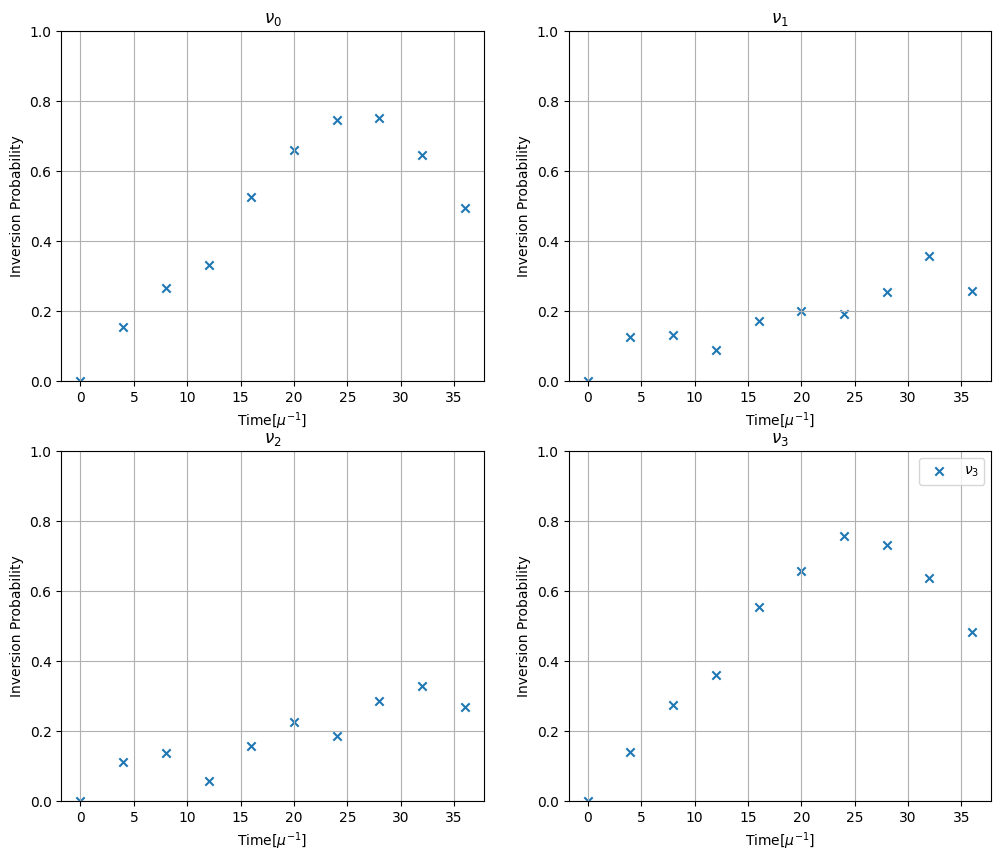

In [158]:
# Lists to store energy values and probabilities
E = 1
T_list = []
P_list_0 = []
P_list_1 = []

begin = [0, 0, 1, 1]

mov1 = 4 * E / dm21 / N

shots = 512
for i in range(N):
    P_list_0.append([])
    P_list_1.append([])

MEAS_INT = 1 # measurement interval
STEPS = 10
END = 40

STEP = int((END - 0) / STEPS)

for t in tqdm(range(0, END, STEP)):
    # omega=Dm2/(2*E*1e6*hbar) #energy converted to eV
    
    # implement the circuit

    # print(dt)

    dt = STEP * mov1

    # print(dt)

    qc = QuantumCircuit(N, N)
    
    qc.x(2)
    qc.x(3)

    K = int(t / STEP)

    for k in range(K):
        for i in range(N):
            qc.unitary(U1(b, dt), i, label='U1')

        update_interact(qc, dt, E)

    qc.measure(range(N), reversed(range(N)))
    ##### Run the circuit#######
    # initial_layout = [0, 1]
    # pqc = transpile(qc, backend=backend, initial_layout=initial_layout, optimization_level=1)
    # print(pqc.num_qubits)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    pmc = pm.run(qc)
    job = sampler.run([pmc], shots=shots)

    print("Starting job", job.job_id())
    # print("Job status:", job.status())
    # while(job.status().name != "DONE"):
    #     time.sleep(10) # keep pulling for result
    #     print("Job status:", job.status())
    # print("job done")

    job_result = job.result()
    print("result received")

    counts = job_result[0].data.c.get_counts()

    # Store values
    T_list.append(t)
    for i in range(N):
        probability_0 = 0
        probability_1 = 0
        # print(counts)
        for key, value in counts.items():
            if key[i] == '0':
                probability_0 += value
            else:
                probability_1 += value
        probability_0 /= shots
        probability_1 /= shots
        P_list_0[i].append(probability_0)
        P_list_1[i].append(probability_1)

    np.save('T_list_sbn.npy', T_list)
    np.save('P_list_0.npy', P_list_0)
    np.save('P_list_1.npy', P_list_1)

    
    #print (E/1e6, probability_nue, probability_numu)
     ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    #probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E / 1e6:.2f} MeV -> Probability: {probability}")
# # Load the classical GLoBES results from the file
# glb_E, glb_P_nue, glb_P_numu = np.loadtxt("prob_nue_numu_Kamland.dat", unpack=True)


# Plot the probabilities
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

# Plot quantum simulation results
# plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
# plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
exp_val = [[] for i in range(N)]
for i in range(N):
    for j in range(len(T_list)):
        n0 = P_list_0[i][j]
        n1 = P_list_1[i][j]
        expectation = n0 - n1
        init_exp = 0
        if begin[i] == 0:
            init_exp = 1
        else:
            init_exp = -1
        expectation = np.abs(init_exp - expectation) / 2
        # exp_val[i].append(expectation)
        # expectation = np.abs(begin[i] - expectation) / 2
        exp_val[i].append(expectation)
    ax[i].scatter(np.asarray(T_list), exp_val[i], label=rf'$\nu_{i}$', marker='x')

# # Plot classical GLoBES results from the data file
# plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
# plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
# Fix the x-axis range
# plt.xlim(0, 12)  # Set range explicitly

# Fix x-axis formatting to avoid scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))


# Labels and title
for i in range(N):
    ax[i].set_xlabel(r"Time[$\mu^{-1}$]")
    ax[i].set_ylabel("Inversion Probability")
    ax[i].set_title(rf'$\nu_{i}$')
    ax[i].set_ylim(0, 1)
plt.legend()
for i in range(N):
    ax[i].grid()
# plt.savefig('sbn.pdf')
# plt.savefig('sbn.png')
plt.show()
    
   

  0%|          | 0/75 [00:00<?, ?it/s]

Starting job czmb9xqp3xeg008hacj0


  1%|▏         | 1/75 [00:07<09:36,  7.79s/it]

result received
Starting job czmb9zza980g008hpddg


  3%|▎         | 2/75 [00:16<10:06,  8.31s/it]

...

result received
Starting job czmbffdqw630008th010


 99%|█████████▊| 74/75 [12:00<00:11, 11.21s/it]

result received
Starting job czmbfj6tj3e0008jw8hg


100%|██████████| 75/75 [12:12<00:00,  9.76s/it]

result received


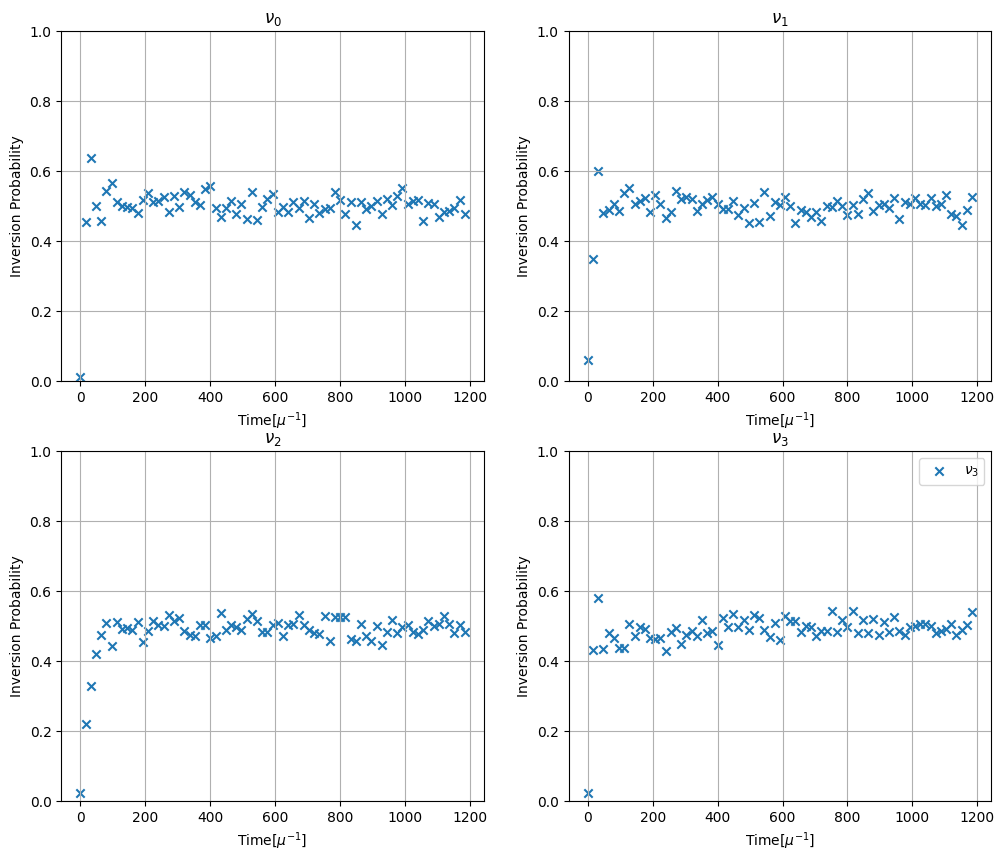

In [168]:
# Lists to store energy values and probabilities
E = 1
T_list = []
P_list_0 = []
P_list_1 = []

begin = [0, 0, 1, 1]

mov1 = 4 * E / dm21 / N

shots = 1024
for i in range(N):
    P_list_0.append([])
    P_list_1.append([])

MEAS_INT = 1 # measurement interval
STEPS = 75
END = 1200

STEP = int((END - 0) / STEPS)

for t in tqdm(range(0, END, STEP)):
    # omega=Dm2/(2*E*1e6*hbar) #energy converted to eV
    
    # implement the circuit

    # print(dt)

    dt = STEP * mov1

    # print(dt)

    qc = QuantumCircuit(N, N)
    
    qc.x(2)
    qc.x(3)

    K = int(t / STEP)

    for k in range(K):
        for i in range(N):
            qc.unitary(U1(b, dt), i, label='U1')

        update_interact(qc, dt, E)

    qc.measure(range(N), reversed(range(N)))
    ##### Run the circuit#######
    # initial_layout = [0, 1]
    # pqc = transpile(qc, backend=backend, initial_layout=initial_layout, optimization_level=1)
    # print(pqc.num_qubits)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=0)
    pmc = pm.run(qc)
    job = sampler.run([pmc], shots=shots)

    print("Starting job", job.job_id())
    # print("Job status:", job.status())
    # while(job.status().name != "DONE"):
    #     time.sleep(10) # keep pulling for result
    #     print("Job status:", job.status())
    # print("job done")

    job_result = job.result()
    print("result received")

    counts = job_result[0].data.c.get_counts()

    # Store values
    T_list.append(t)
    for i in range(N):
        probability_0 = 0
        probability_1 = 0
        # print(counts)
        for key, value in counts.items():
            if key[i] == '0':
                probability_0 += value
            else:
                probability_1 += value
        probability_0 /= shots
        probability_1 /= shots
        P_list_0[i].append(probability_0)
        P_list_1[i].append(probability_1)

    np.save('T_list_sbn.npy', T_list)
    np.save('P_list_0.npy', P_list_0)
    np.save('P_list_1.npy', P_list_1)

    
    #print (E/1e6, probability_nue, probability_numu)
     ###### The following two lines print energy and both nu_e and nu_mu probabilities########
    #probability = {state: count / 1024 for state, count in counts.items()}
    #print(f"E = {E / 1e6:.2f} MeV -> Probability: {probability}")
# # Load the classical GLoBES results from the file
# glb_E, glb_P_nue, glb_P_numu = np.loadtxt("prob_nue_numu_Kamland.dat", unpack=True)


# Plot the probabilities
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax = ax.flatten()

# Plot quantum simulation results
# plt.plot(E_list, P_nue_list, label=r'P($\nu_e \to \nu_e$), quantum simulation', linestyle='-', color='blue')
# plt.plot(E_list, P_numu_list, label=r'P($\nu_e \to \nu_\mu$), quantum simulation', linestyle='-', color='red')
exp_val = [[] for i in range(N)]
for i in range(N):
    for j in range(len(T_list)):
        n0 = P_list_0[i][j]
        n1 = P_list_1[i][j]
        expectation = n0 - n1
        init_exp = 0
        if begin[i] == 0:
            init_exp = 1
        else:
            init_exp = -1
        expectation = np.abs(init_exp - expectation) / 2
        # exp_val[i].append(expectation)
        # expectation = np.abs(begin[i] - expectation) / 2
        exp_val[i].append(expectation)
    ax[i].scatter(np.asarray(T_list), exp_val[i], label=rf'$\nu_{i}$', marker='x')

# # Plot classical GLoBES results from the data file
# plt.plot(glb_E, glb_P_nue, linestyle='--', color='blue', linewidth=2, label=r'P($\nu_e \to \nu_e$), GLoBES')
# plt.plot(glb_E, glb_P_numu, linestyle='--', color='red', linewidth=2, label=r'P($\nu_e \to \nu_\mu$), GLoBES')
# Fix the x-axis range
# plt.xlim(0, 12)  # Set range explicitly

# Fix x-axis formatting to avoid scientific notation
plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.0f}"))


# Labels and title
for i in range(N):
    ax[i].set_xlabel(r"Time[$\mu^{-1}$]")
    ax[i].set_ylabel("Inversion Probability")
    ax[i].set_title(rf'$\nu_{i}$')
    ax[i].set_ylim(0, 1)
plt.legend()
for i in range(N):
    ax[i].grid()
# plt.savefig('sbn.pdf')
# plt.savefig('sbn.png')
plt.show()
    
   